# Demo Notebook: Plant Disease Classification

In [1]:
# All library imports + getting the trained model

import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))

import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

from src.model import get_model
from config import MODEL_SAVE_PATH

print("Imports OK!")


Imports OK!


In [2]:

# Defining all 15 classes
CLASSES = [
    'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy',
    'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy',
    'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight',
    'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot',
    'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot',
    'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus',
    'Tomato_healthy'
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_model(num_classes=len(CLASSES)).to(device)
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.eval()
print(f"Model loaded on {device}")


Model loaded on cpu


In [3]:

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Create a grad-CAM heatmap over the image, highlighting important areas which 
# the model looked at for classification.
def predict_with_gradcam(image_path):
    # Load Image
    image = Image.open(image_path).convert("RGB")
    image_resized = image.resize((224, 224))
    image_np = np.array(image_resized) / 255.0

    input_tensor = transform(image).unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)

    top3_probs, top3_indices = probs.topk(3, dim=1)
    predicted_class = CLASSES[top3_indices[0][0].item()]
    confidence = top3_probs[0][0].item() * 100

    # Grad-CAM
    target_layers = [model.features[-1]]
    cam = GradCAM(model=model, target_layers=target_layers)
    targets = [ClassifierOutputTarget(top3_indices[0][0].item())]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    cam_image = show_cam_on_image(image_np.astype(np.float32), grayscale_cam, use_rgb=True)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f"Prediction: {predicted_class}  |  Confidence: {confidence:.1f}%", 
                 fontsize=13, fontweight='bold')

    axes[0].imshow(image_resized)
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    axes[1].imshow(cam_image)
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis('off')

    # Top-3 bar chart
    labels = [CLASSES[i.item()].replace('_', ' ') for i in top3_indices[0]]
    values = [p.item() * 100 for p in top3_probs[0]]
    colors = ['#2ecc71', '#3498db', '#e74c3c']
    axes[2].barh(labels, values, color=colors)
    axes[2].set_xlim(0, 100)
    axes[2].set_xlabel("Confidence (%)")
    axes[2].set_title("Top-3 Predictions")
    for i, v in enumerate(values):
        axes[2].text(v + 1, i, f"{v:.1f}%", va='center')

    plt.tight_layout()
    plt.show()

    return predicted_class, confidence


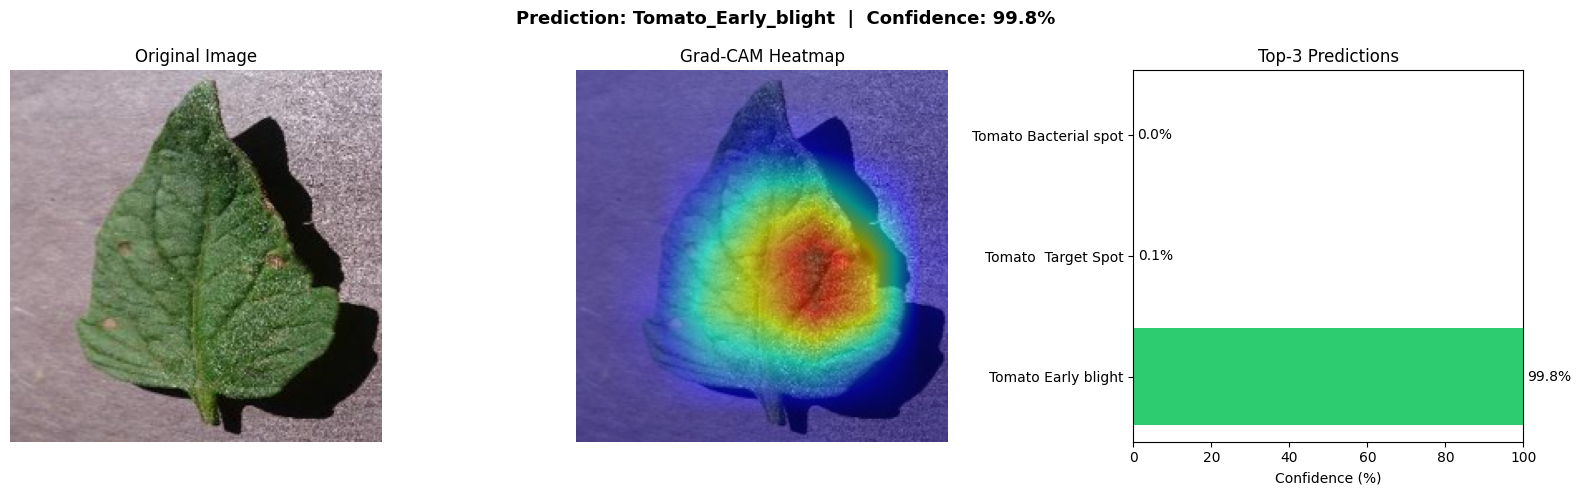

In [5]:

# Change path to any Image from the raw folder
IMAGE_PATH = "../data/raw/PlantVillage/Tomato_Early_blight/0a2726e0-3358-4a46-b6dc-563a5a9f2bdf___RS_Erly.B 7860.JPG"

predicted_class, confidence = predict_with_gradcam(IMAGE_PATH)


--- Sick ---


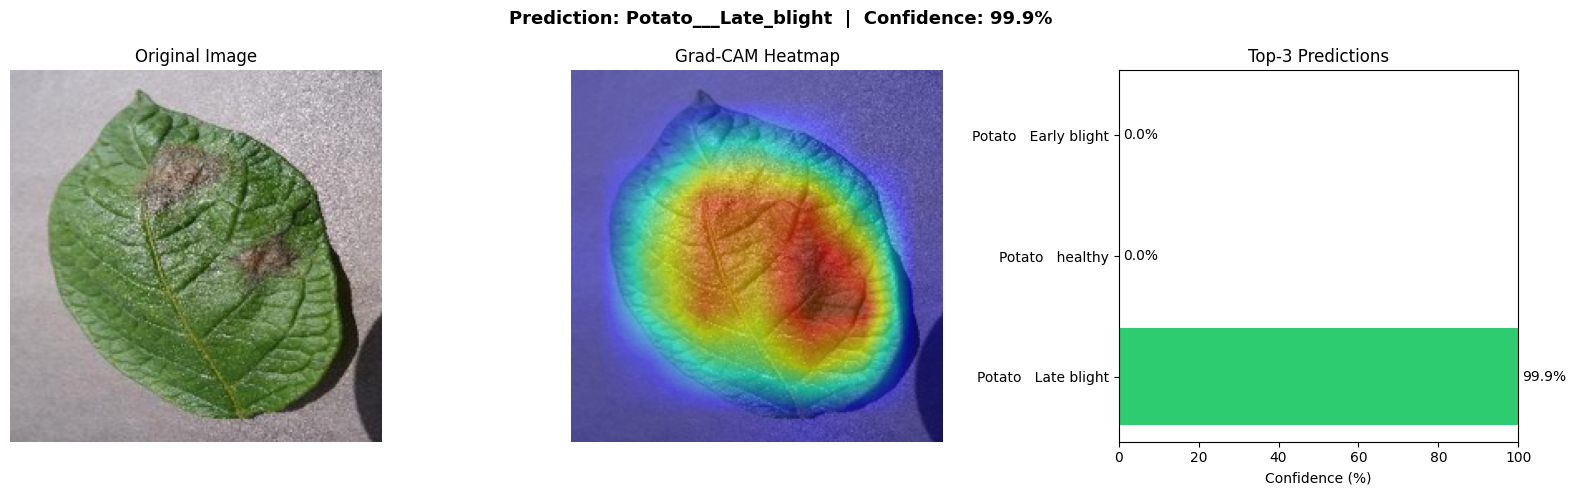

--- Healthy ---


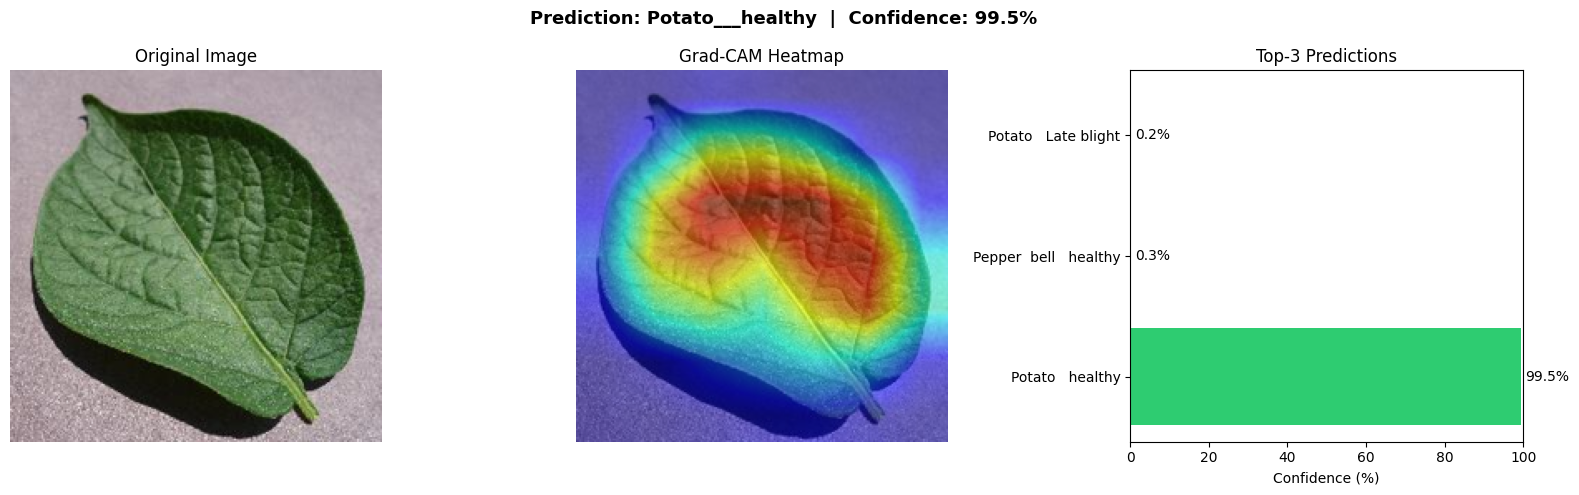

('Potato___healthy', 99.49209094047546)

In [8]:

# Compare sick leaf vs. healthy leaf
diseased_path = "../data/raw/PlantVillage/Potato___Late_blight/0acdc2b2-0dde-4073-8542-6fca275ab974___RS_LB 4857.JPG"
healthy_path = "../data/raw/PlantVillage/Potato___healthy/0b3e5032-8ae8-49ac-8157-a1cac3df01dd___RS_HL 1817.JPG"



print("--- Sick ---")
predict_with_gradcam(diseased_path)

print("--- Healthy ---")
predict_with_gradcam(healthy_path)
